<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/HAR_QTFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
from google.colab import userdata
import sys
from google.colab import drive
import scipy.stats as stats
# from arch import arch_model
# from arch.univariate import ConstantMean, GARCH, StudentsT, FIGARCH
data_futures = pd.read_csv(userdata.get('data_path'))

In [7]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["symbol"].isin(["ES", "CL", "C", "GC", "NG"])].sort_values(
    ["symbol", "date"]
)

# 2. Daily percentage log returns
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)

# 3. Realized Volatility metrics & Multi-Horizon Rolling Windows
# (Grouping by symbol prevents data leakage across assets)
data["log_rv5"] = np.log(data["rv5"])
data["rv5_scaled"] = data["rv5"] * 10000

data["log_rv5_w"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=5).mean()
)
data["log_rv5_m"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=22).mean()
)

# 4. Pivot into wide DataFrame
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv5", "rv5", "rv5_scaled", "log_rv5_w", "log_rv5_m"],
)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]
df = df.dropna().copy()

In [8]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-67.0871,0.0000e+00,0.0657,0.1,Stationary
ret_CL,-10.5924,6.4755e-19,0.0416,0.1,Stationary
ret_ES,-14.8572,1.7409e-27,0.0225,0.1,Stationary
ret_GC,-65.6566,0.0000e+00,0.3397,0.1,Stationary
ret_NG,-68.6773,0.0000e+00,0.0285,0.1,Stationary


In [10]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "log" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv5_C,-6.7954,2.3085e-09,1.0955,0.0100,Contradictory / Structural Break
log_rv5_CL,-4.9313,3.0296e-05,1.4041,0.0100,Contradictory / Structural Break
log_rv5_ES,-6.1309,8.4060e-08,0.3686,0.0907,Stationary
log_rv5_GC,-5.6447,1.0178e-06,0.8071,0.0100,Contradictory / Structural Break
log_rv5_NG,-4.4241,2.6900e-04,3.2578,0.0100,Contradictory / Structural Break
log_rv5_w_C,-5.3145,5.1092e-06,1.0602,0.0100,Contradictory / Structural Break
log_rv5_w_CL,-4.8405,4.5463e-05,1.4170,0.0100,Contradictory / Structural Break
log_rv5_w_ES,-5.6651,9.1896e-07,0.3582,0.0952,Stationary
log_rv5_w_GC,-4.9771,2.4633e-05,0.7824,0.0100,Contradictory / Structural Break


IndexError: index 5 is out of bounds for axis 0 with size 5

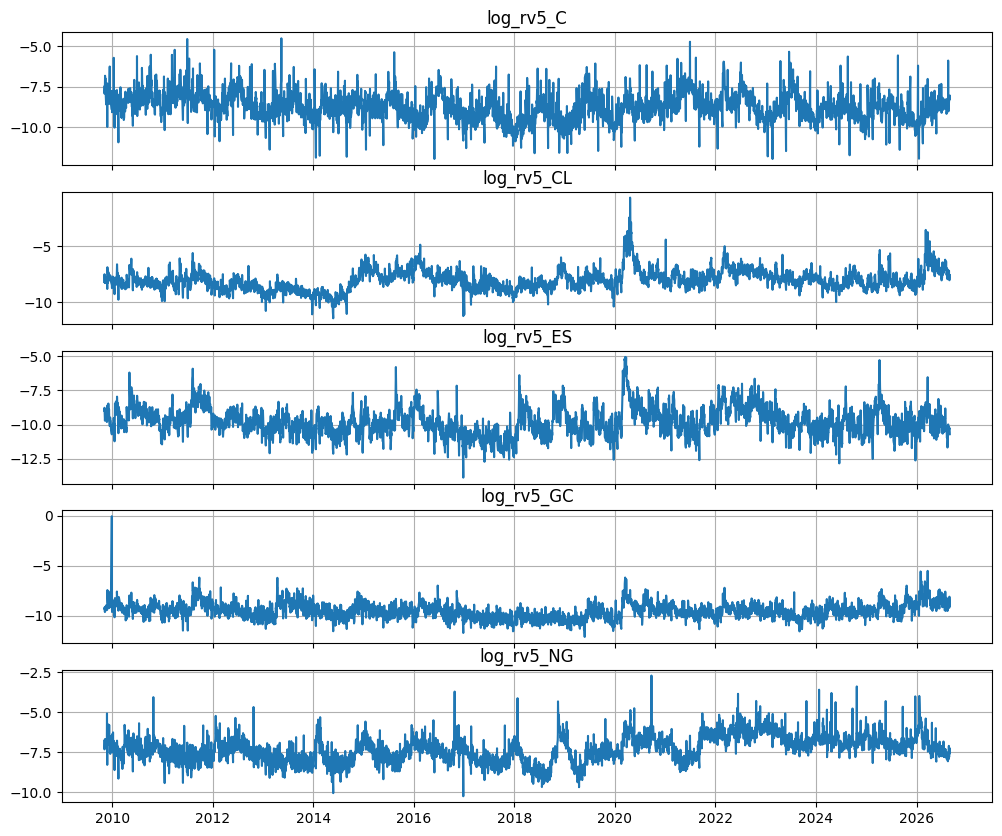

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "log_rv5_" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [25]:
df

,close_price_C,close_price_CL,close_price_ES,close_price_GC,close_price_NG,ret_C,ret_CL,ret_ES,ret_GC,ret_NG,...,log_rv5_w_C,log_rv5_w_CL,log_rv5_w_ES,log_rv5_w_GC,log_rv5_w_NG,log_rv5_m_C,log_rv5_m_CL,log_rv5_m_ES,log_rv5_m_GC,log_rv5_m_NG
date,,,,,,,,,,,,,,,,,,,,,
2009-11-05,376.375,80.075,1061.625,1091.70,4.7695,-2.265735,0.362818,1.829899,0.325711,0.546622,...,-7.428655,-7.944453,-8.471744,-9.023431,-6.850705,-7.550138,-7.898249,-8.983038,-8.885648,-6.467564
2009-11-06,366.875,77.625,1066.375,1097.20,4.6045,-2.556480,-3.107416,0.446429,0.502537,-3.520739,...,-7.495733,-7.827901,-8.554424,-8.962580,-6.992761,-7.553291,-7.903720,-8.975024,-8.875545,-6.494311
2009-11-09,381.625,79.055,1090.125,1102.15,4.6045,3.941726,1.825427,2.202732,0.450134,0.000000,...,-7.541129,-7.972432,-8.905544,-9.087063,-7.002944,-7.533502,-7.932700,-8.987838,-9.231745,-6.514682
2009-11-10,393.125,78.875,1093.125,1109.25,4.4895,2.968918,-0.227949,0.274820,0.642129,-2.529275,...,-7.503830,-7.958449,-9.127712,-9.175588,-6.997737,-7.515796,-7.928849,-8.978965,-9.217974,-6.518916
2009-11-11,392.500,79.290,1092.375,1119.40,4.4895,-0.159109,0.524770,-0.068634,0.910872,0.000000,...,-7.420661,-7.999229,-9.288715,-9.287451,-6.995603,-7.503375,-7.930034,-8.952049,-9.196931,-6.522296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-25,527.250,80.260,7689.875,4700.05,2.8575,1.697590,-6.236743,0.191995,0.237513,1.765271,...,-8.066211,-7.612352,-10.391822,-8.610813,-7.527315,-8.592373,-7.175386,-10.315018,-8.783565,-7.657032
2026-08-26,535.375,81.835,7725.875,4679.60,2.9215,1.529262,1.943366,0.467056,-0.436051,2.215007,...,-8.529034,-7.650310,-10.434896,-8.728057,-7.576291,-8.589383,-7.226959,-10.344912,-8.763352,-7.665458
2026-08-27,536.250,83.105,7741.625,4632.15,2.9225,0.163303,1.539984,0.203653,-1.019151,0.034223,...,-8.391776,-7.624077,-10.470540,-8.837828,-7.500946,-8.566112,-7.296946,-10.379293,-8.770078,-7.643579


In [26]:
def fit_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    metric="log_rv5",
    include_exog_horizons=False,
    include_leverage=False,  # Toggle for Corsi-Renò Leverage terms
    hac_lags=22,
):
  """Fits an OLS HAR, HAR-X, LHAR, or LHAR-X model with Newey-West standard errors.

  Parameters:
  -----------
  df_wide : pd.DataFrame
      Clean wide DataFrame aligned by date.
  target : str
      Target asset symbol (e.g. 'ES').
  exog_symbols : list of str, optional
      List of exogenous assets (e.g. ['CL'], ['CL', 'C'], or ['CL', 'C', 'GC',
      'NG']).
  metric : str
      Prefix for realized volatility metric (e.g. 'log_rv5' or 'rk_scaled').
  include_exog_horizons : bool
      If False: includes only daily lag-1 of exog.
      If True: includes daily, weekly, and monthly components for each exog
      asset.
  include_leverage : bool
      If True: includes daily, weekly, and monthly negative return shocks |min(r,
      0)|.
  hac_lags : int
      Newey-West truncation lag parameter.
  """
  if exog_symbols is None:
    exog_symbols = []

  # 1. Target: tomorrow's realized volatility (t+1)
  y_target = df_wide[f"{metric}_{target}"].shift(-1)

  # 2. Endogenous HAR components for target asset (at day t)
  X_dict = {
      f"{target}_d": df_wide[f"{metric}_{target}"],
      f"{target}_w": df_wide[f"{metric}_w_{target}"],
      f"{target}_m": df_wide[f"{metric}_m_{target}"],
  }

  # 3. Leverage components (Corsi & Renò)
  if include_leverage:
    ret = df_wide[f"ret_{target}"] / 100.0  # Convert % returns to decimals
    ret_w = ret.rolling(5).mean()
    ret_m = ret.rolling(22).mean()

    X_dict[f"{target}_down_d"] = np.abs(np.minimum(ret, 0.0))
    X_dict[f"{target}_down_w"] = np.abs(np.minimum(ret_w, 0.0))
    X_dict[f"{target}_down_m"] = np.abs(np.minimum(ret_m, 0.0))

  # 4. Add Exogenous Regressors
  for sym in exog_symbols:
    if include_exog_horizons:
      X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]
      X_dict[f"{sym}_w"] = df_wide[f"{metric}_w_{sym}"]
      X_dict[f"{sym}_m"] = df_wide[f"{metric}_m_{sym}"]
    else:
      X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]

  # 5. Construct design matrix & align sample
  design_df = pd.DataFrame(X_dict)
  design_df["target_t1"] = y_target
  design_df = design_df.dropna()

  y = design_df["target_t1"]
  X = sm.add_constant(design_df.drop(columns=["target_t1"]))

  # 6. Fit OLS with HAC standard errors
  model = sm.OLS(y, X)
  results = model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

  return results

In [28]:
# 1. Standard HAR Models (include_leverage=False)
model_es_solo = fit_har_x(df, target="ES", include_leverage=False)
model_har_oil = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_corn = fit_har_x(
    df,
    target="ES",
    exog_symbols=["C"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_both = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_all = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    include_exog_horizons=True,
    include_leverage=False,
)

# 2. Leverage LHAR Models (include_leverage=True)
model_lhar_solo = fit_har_x(df, target="ES", include_leverage=True)
model_lhar_oil = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_corn = fit_har_x(
    df,
    target="ES",
    exog_symbols=["C"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_both = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_all = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    include_exog_horizons=True,
    include_leverage=True,
)

# 3. Assemble all 10 models
models_all = {
    # Standard HAR Family
    "Baseline HAR": model_es_solo,
    "HAR-X (Oil)": model_har_oil,
    "HAR-X (Corn)": model_har_corn,
    "HAR-X (Oil + Corn)": model_har_both,
    "HAR-X (All 4)": model_har_all,
    # Leverage LHAR Family
    "Baseline LHAR": model_lhar_solo,
    "LHAR-X (Oil)": model_lhar_oil,
    "LHAR-X (Corn)": model_lhar_corn,
    "LHAR-X (Oil + Corn)": model_lhar_both,
    "LHAR-X (All 4)": model_lhar_all,
}

# 4. Build the comparison table matching your output format
summary_table_10 = pd.DataFrame(
    {
        "R²": [m.rsquared for m in models_all.values()],
        "Adj. R²": [m.rsquared_adj for m in models_all.values()],
        "AIC": [m.aic for m in models_all.values()],
        "BIC": [m.bic for m in models_all.values()],
        "F-Stat": [m.fvalue for m in models_all.values()],
        "Prob(F-Stat)": [m.f_pvalue for m in models_all.values()],
        "Log-Likelihood": [m.llf for m in models_all.values()],
    },
    index=models_all.keys(),
)

print(summary_table_10.round(4))

                         R²  Adj. R²        AIC        BIC     F-Stat  \
Baseline HAR         0.6963   0.6961  7284.7925  7310.2505  2420.9285   
HAR-X (Oil)          0.6965   0.6961  7287.9551  7332.5066  1312.8480   
HAR-X (Corn)         0.6966   0.6962  7286.5559  7331.1075  1239.1838   
HAR-X (Oil + Corn)   0.6969   0.6963  7288.5882  7352.2333   889.6033   
HAR-X (All 4)        0.6984   0.6973  7279.4583  7381.2904   594.4885   
Baseline LHAR        0.7243   0.7239  6855.6132  6900.1304  1990.9230   
LHAR-X (Oil)         0.7246   0.7240  6857.0089  6920.6050  1346.5271   
LHAR-X (Corn)        0.7244   0.7238  6860.4684  6924.0644  1342.8829   
LHAR-X (Oil + Corn)  0.7247   0.7240  6861.1356  6943.8104  1026.0938   
LHAR-X (All 4)       0.7267   0.7255  6843.2419  6964.0743   721.1834   

                     Prob(F-Stat)  Log-Likelihood  
Baseline HAR                  0.0      -3638.3962  
HAR-X (Oil)                   0.0      -3636.9775  
HAR-X (Corn)                  0.0      -

In [30]:
model_lhar_all.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              target_t1   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     721.2
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        07:51:10   Log-Likelihood:                -3402.6
No. Observations:                4271   AIC:                             6843.
Df Residuals:                    4252   BIC:                             6964.
Df Model:                          18                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5063      0.185     -8.123      0.000      -1.870      -1.143
ES_d           0.4110      0.025     16.347      0.000       0.362       0.460
ES_w           0.2716      0.032      8.603      0.000       0.210       0.334
ES_m           0.1441      0.024      5.996      0.000       0.097       0.191
ES_down_d     19.2785      1.855     10.390      0.000      15.642      22.915
ES_down_w     29.2195      4.304      6.789      0.000      20.784      37.655
ES_down_m     22.7720      9.156      2.487      0.013       4.827      40.717
CL_d           0.0573      0.026      2.235      0.025       0.007       0.108
CL_w          -0.0818      0.038     -2.176      0.030      -0.155      -0.008
CL_m           0.0159      0.029      0.552      0.581      -0.041       0.072
C_d           -0.0167      0.015     -1.084      0.278      -0.047       0.013
C_w            0.0248      0.032      0.783      0.434      -0.037       0.087
C_m           -0.0029      0.031     -0.095      0.924      -0.063       0.058
GC_d          -0.0549      0.025     -2.228      0.026      -0.103      -0.007
GC_w          -0.0083      0.036     -0.231      0.817      -0.079       0.062
GC_m           0.0660      0.031      2.145      0.032       0.006       0.126
NG_d          -0.0223      0.023     -0.989      0.323      -0.066       0.022
NG_w          -0.0566      0.037     -1.522      0.128      -0.130       0.016
NG_m           0.1194      0.032      3.722      0.000       0.057       0.182
==============================================================================
Omnibus:                      201.954   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              526.492
Skew:                           0.244   Prob(JB):                    4.72e-115
Kurtosis:                       4.649   Cond. No.                     3.79e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 22 lags and without small sample correction
[2] The condition number is large, 3.79e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
def plot_har_residual_diagnostics(
    model_results, date_index=None, model_name="HAR-RV (ES)", lags=20, bins=70
):
    """Plots a 4-panel residual diagnostic grid for an OLS/HAR regression model."""
    # 1. Extract 1D residual series
    resid = model_results.resid

    # Attach proper date index if supplied (dropped last row due to t+1 forecast)
    if date_index is not None:
        resid = pd.Series(resid.values, index=date_index[: len(resid)])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(
        resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85
    )
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(
        f"Residuals Over Time: {model_name}", fontweight="bold"
    )
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(
        resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none"
    )
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (Normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf,
        stats.norm.pdf(x_pdf, mu, std),
        "r--",
        lw=2,
        label=rf"Normal ($\mu={mu:.3f},\ \sigma={std:.3f}$)",
    )
    axes[0, 1].set_title(
        f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})",
        fontweight="bold",
    )
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(
        f"Residual ACF (Up to {lags} Lags)", fontweight="bold"
    )
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_har_residual_diagnostics(
    model_har_all, date_index=df.index[:-1], model_name="ES Solo HAR"
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm


def forecast_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    metric="log_rv5",
    exog_lags=1,
    forecast_horizon=500,
    alpha=0.05,
    rolling=False,
):
    """Generates out-of-sample 1-step-ahead forecasts with prediction intervals.

    Parameters:
    -----------
    df_wide : pd.DataFrame
        Clean wide DataFrame aligned by date.
    target : str
        Target asset symbol (e.g., 'ES').
    exog_symbols : list of str, optional
        List of exogenous assets (e.g., ['CL'], ['CL', 'GC']).
    metric : str
        Realized volatility metric prefix (e.g., 'log_rv5').
    exog_lags : int
        Number of lags to include for each exogenous regressor (default: 1).
    forecast_horizon : int
        Number of out-of-sample trading days to predict (e.g., 500).
    alpha : float
        Significance level for prediction intervals (0.05 = 95% confidence).
    rolling : bool
        If False, uses expanding estimation window; if True, uses fixed-length rolling window.

    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with Actuals, Forecasts, Lower/Upper Intervals, and Residuals.
    metrics : dict
        RMSE, MAE, QLIKE, Empirical Coverage Rate, R2_OOS, and R2_Pred_Corr.
    """
    if exog_symbols is None:
        exog_symbols = []

    # 1. Construct Target Series (Tomorrow's RV: t+1)
    y_target = df_wide[f"{metric}_{target}"].shift(-1)

    # 2. Build Design Matrix (Information available at day t)
    # Endogenous Corsi components for target
    X_dict = {
        f"{target}_d": df_wide[f"{metric}_{target}"],
        f"{target}_w": df_wide[f"{metric}_w_{target}"],
        f"{target}_m": df_wide[f"{metric}_m_{target}"],
    }

    # Exogenous components with user-selected number of lags
    for sym in exog_symbols:
        for lag in range(1, exog_lags + 1):
            X_dict[f"{sym}_lag{lag}"] = df_wide[f"{metric}_{sym}"].shift(lag - 1)

    design_df = pd.DataFrame(X_dict)
    design_df["target_t1"] = y_target
    design_df = design_df.dropna()

    T_total = len(design_df)
    if forecast_horizon >= T_total:
        raise ValueError(
            f"forecast_horizon ({forecast_horizon}) must be smaller than sample length ({T_total})."
        )

    # In-sample vs. Out-of-sample split boundary
    train_size = T_total - forecast_horizon

    y_full = design_df["target_t1"]
    X_full = sm.add_constant(design_df.drop(columns=["target_t1"]))

    forecasts = []
    actuals = []
    lower_bounds = []
    upper_bounds = []
    benchmark_preds = []  # Prevailing historical mean up to day t
    dates = []

    # Critical value from standard normal for (1 - alpha) interval
    z_crit = stats.norm.ppf(1 - alpha / 2)

    # 3. Recursive Out-of-Sample Estimation Loop
    for i in range(forecast_horizon):
        t_idx = train_size + i

        # Expanding vs Rolling window selection
        if rolling:
            X_train = X_full.iloc[i:t_idx]
            y_train = y_full.iloc[i:t_idx]
        else:
            X_train = X_full.iloc[:t_idx]
            y_train = y_full.iloc[:t_idx]

        # Forecast vector at time t (to forecast t+1)
        x_pred = X_full.iloc[[t_idx]]
        actual_val = y_full.iloc[t_idx]
        pred_date = design_df.index[t_idx]

        # Record unconditional benchmark (prevailing historical mean up to t)
        benchmark_preds.append(y_train.mean())

        # Fit model on training slice
        model = sm.OLS(y_train, X_train).fit()

        # Point forecast
        y_hat = float(model.predict(x_pred).iloc[0])

        # Analytical Prediction Interval Error:
        # SE_pred = s * sqrt(1 + x_0 * (X'X)^(-1) * x_0')
        s2 = model.mse_resid
        X_mat = X_train.to_numpy()
        x_vec = x_pred.to_numpy().reshape(-1, 1)

        try:
            XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
            leverage = float((x_vec.T @ XtX_inv @ x_vec).item())
        except np.linalg.LinAlgError:
            leverage = 0.0

        se_pred = np.sqrt(s2 * (1.0 + leverage))

        # Interval bounds
        lower = y_hat - z_crit * se_pred
        upper = y_hat + z_crit * se_pred

        forecasts.append(y_hat)
        actuals.append(actual_val)
        lower_bounds.append(lower)
        upper_bounds.append(upper)
        dates.append(pred_date)

    # 4. Compile Forecast Results
    res_df = pd.DataFrame(
        {
            "Actual": actuals,
            "Forecast": forecasts,
            "Benchmark_Mean": benchmark_preds,
            "Lower_CI": lower_bounds,
            "Upper_CI": upper_bounds,
            "Error": np.array(actuals) - np.array(forecasts),
        },
        index=pd.to_datetime(dates),
    )

    # 5. Evaluate Performance Metrics
    actual_arr = np.array(actuals)
    forecast_arr = np.array(forecasts)
    bench_arr = np.array(benchmark_preds)

    # Errors
    model_mse = np.mean((actual_arr - forecast_arr) ** 2)
    bench_mse = np.mean((actual_arr - bench_arr) ** 2)

    rmse = np.sqrt(model_mse)
    mae = np.mean(np.abs(res_df["Error"]))

    # Out-of-Sample Campbell-Thompson R²
    r2_oos = 1.0 - (model_mse / bench_mse)

    # Squared Correlation R² (Mincer-Zarnowitz style)
    corr_matrix = np.corrcoef(actual_arr, forecast_arr)
    r2_corr = corr_matrix[0, 1] ** 2

    # Empirical coverage: % of actuals within prediction bands
    coverage = np.mean(
        (res_df["Actual"] >= res_df["Lower_CI"])
        & (res_df["Actual"] <= res_df["Upper_CI"])
    )

    # QLIKE Loss Function
    diff = res_df["Actual"] - res_df["Forecast"]
    qlike = np.mean(np.exp(diff) - diff - 1)

    eval_metrics = {
        "RMSE": round(float(rmse), 4),
        "MAE": round(float(mae), 4),
        "QLIKE": round(float(qlike), 4),
        "Coverage_Rate": f"{coverage * 100:.2f}%",
        "R2_OOS": f"{r2_oos * 100:.2f}%",
        "R2_Pred_Corr": f"{r2_corr * 100:.2f}%",
    }

    return res_df, eval_metrics

In [ ]:
forecast_har_x(df, exog_symbols=['C', 'CL', 'GC', 'NG'])